## Algerian Forest Fires Dataset 
Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attribues and 1 output attribue (class)
The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.

Attribute Information:

1. Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations
2. Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH : Relative Humidity in %: 21 to 90
4. Ws :Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8
FWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

In [518]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline


In [519]:
dataset =  pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv",  header = 1) 
#there is header is used for remove the first header line of the dataset as it is the name of the dataset

dataset

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
242,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
243,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
244,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [520]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [521]:
# missing values

dataset.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [522]:
dataset[dataset.isnull().any(axis= 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


#### Observation

- there is a anothe dataset starts at line 122 which is header of the dataset
- we can resolve it by adding a new column REGION -
- - Bejaia Region Dataset
- - Sidi-Bel Abbes Region  Dataset

In [523]:
dataset.loc[:122,"Region"] = 0
dataset.loc[122:,"Region"] = 1

In [524]:
dataset.Region = dataset.Region.astype(int) # as the previous operation make it a float datatype which consume a lot of space so we change it into the int type which consume less index

In [525]:
dataset[dataset.isnull().any(axis =1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1


In [526]:
dataset.shape

(246, 15)

In [527]:
# remove the null values

dataset.dropna().reset_index(drop=True)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1
240,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1
241,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
242,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [528]:
dataset.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [529]:
dataset = dataset.drop(122).reset_index(drop= True)
dataset.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        1
Region         0
dtype: int64

In [530]:
df.columns  # it shows blank space inconsistency in the naming process we need to clean it to visually perfection also

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [531]:
dataset.columns= dataset.columns.str.strip()

In [532]:
dataset.columns


Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

#### change require in datatype of our dataset points which are now only object

In [533]:
dataset.head() 

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [534]:
cols = ['day','month','year','Temperature', 'RH', "Ws"]

for col in cols:
    print(dataset[~dataset[col].astype(str).str.isnumeric()][col])

122    day
Name: day, dtype: object
122    month
Name: month, dtype: object
122    year
Name: year, dtype: object
122    Temperature
Name: Temperature, dtype: object
122     RH
Name: RH, dtype: object
122     Ws
Name: Ws, dtype: object


In [535]:
dataset.drop(index=122, inplace=True)

In [536]:
cols = ['day','month','year','Temperature', 'RH', "Ws"]

dataset[cols] = dataset[cols].astype(int)

In [537]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 244
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          244 non-null    int64 
 1   month        244 non-null    int64 
 2   year         244 non-null    int64 
 3   Temperature  244 non-null    int64 
 4   RH           244 non-null    int64 
 5   Ws           244 non-null    int64 
 6   Rain         244 non-null    object
 7   FFMC         244 non-null    object
 8   DMC          244 non-null    object
 9   DC           244 non-null    object
 10  ISI          244 non-null    object
 11  BUI          244 non-null    object
 12  FWI          244 non-null    object
 13  Classes      243 non-null    object
 14  Region       244 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 30.5+ KB


In [538]:
object 

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [539]:
object = [features for features in dataset.columns if dataset[features].dtype == 'O' ]

for col in object:
    if col != 'Classes':
        dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

In [540]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 244
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   Temperature  244 non-null    int64  
 4   RH           244 non-null    int64  
 5   Ws           244 non-null    int64  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       244 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 30.5+ KB


In [541]:
dataset[dataset.isna().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
166,14,7,2012,37,37,18,0.2,88.9,12.9,NaN,12.5,10.4,NaN,NaN,1


In [542]:
dataset['FWI'] = dataset['FWI'].fillna(dataset.FWI.mean()) #mean value imputation in FWI carring a NaN value

In [543]:
dataset['FWI'] = dataset['FWI'].fillna(dataset.FWI.mean()) #mean value imputation in FWI carring a NaN value
dataset['DC'] = dataset['DC'].fillna(dataset.DC.mean()) #mean value imputation in FWI carring a NaN value

In [544]:
dataset['Classes'] # categorical data mode value imputation

0       not fire   
1       not fire   
2       not fire   
3       not fire   
4       not fire   
           ...     
240         fire   
241     not fire   
242     not fire   
243     not fire   
244    not fire    
Name: Classes, Length: 244, dtype: object

In [545]:
dataset['Classes'] = dataset['Classes'].fillna(dataset['Classes'].mode()[0])

In [546]:
dataset[dataset.isna().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region


In [547]:
# save the cleaned dataset

dataset.to_csv("Algerian_forest_fires_dataset_Cleaned_me.csv",index =False)

# EDA

In [548]:
data = dataset.drop(['day','month','year'],axis =1)

In [549]:
data

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...
240,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
241,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
242,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
243,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [550]:
data.Classes.value_counts() # many types of not fire indicates there may some blank spaces before or after the not fire phrase

Classes
fire             132
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [551]:
np.where(data['Classes'] == 'not fire')

(array([91, 93]),)

In [552]:
# Encoding of the categories of classes

data['Classes'] = np.where(data['Classes'].str.contains('not fire'),0 ,1)

In [553]:
data[data.Classes == 1]

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
5,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,1,0
6,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,7.2,1,0
7,30,73,15,0.0,86.6,12.1,38.3,5.6,13.5,7.1,1,0
10,31,65,14,0.0,84.5,12.5,54.3,4.0,15.8,5.6,1,0
11,26,81,19,0.0,84.0,13.8,61.4,4.8,17.7,7.1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
233,29,41,8,0.1,83.9,24.9,86.0,2.7,28.9,5.6,1,1
235,35,34,17,0.0,92.2,23.6,97.3,13.8,29.4,21.6,1,1
236,33,64,13,0.0,88.9,26.1,106.3,7.1,32.4,13.7,1,1
237,35,56,14,0.0,89.0,29.4,115.6,7.5,36.0,15.2,1,1


In [554]:
data.Classes.value_counts()

Classes
1    138
0    106
Name: count, dtype: int64

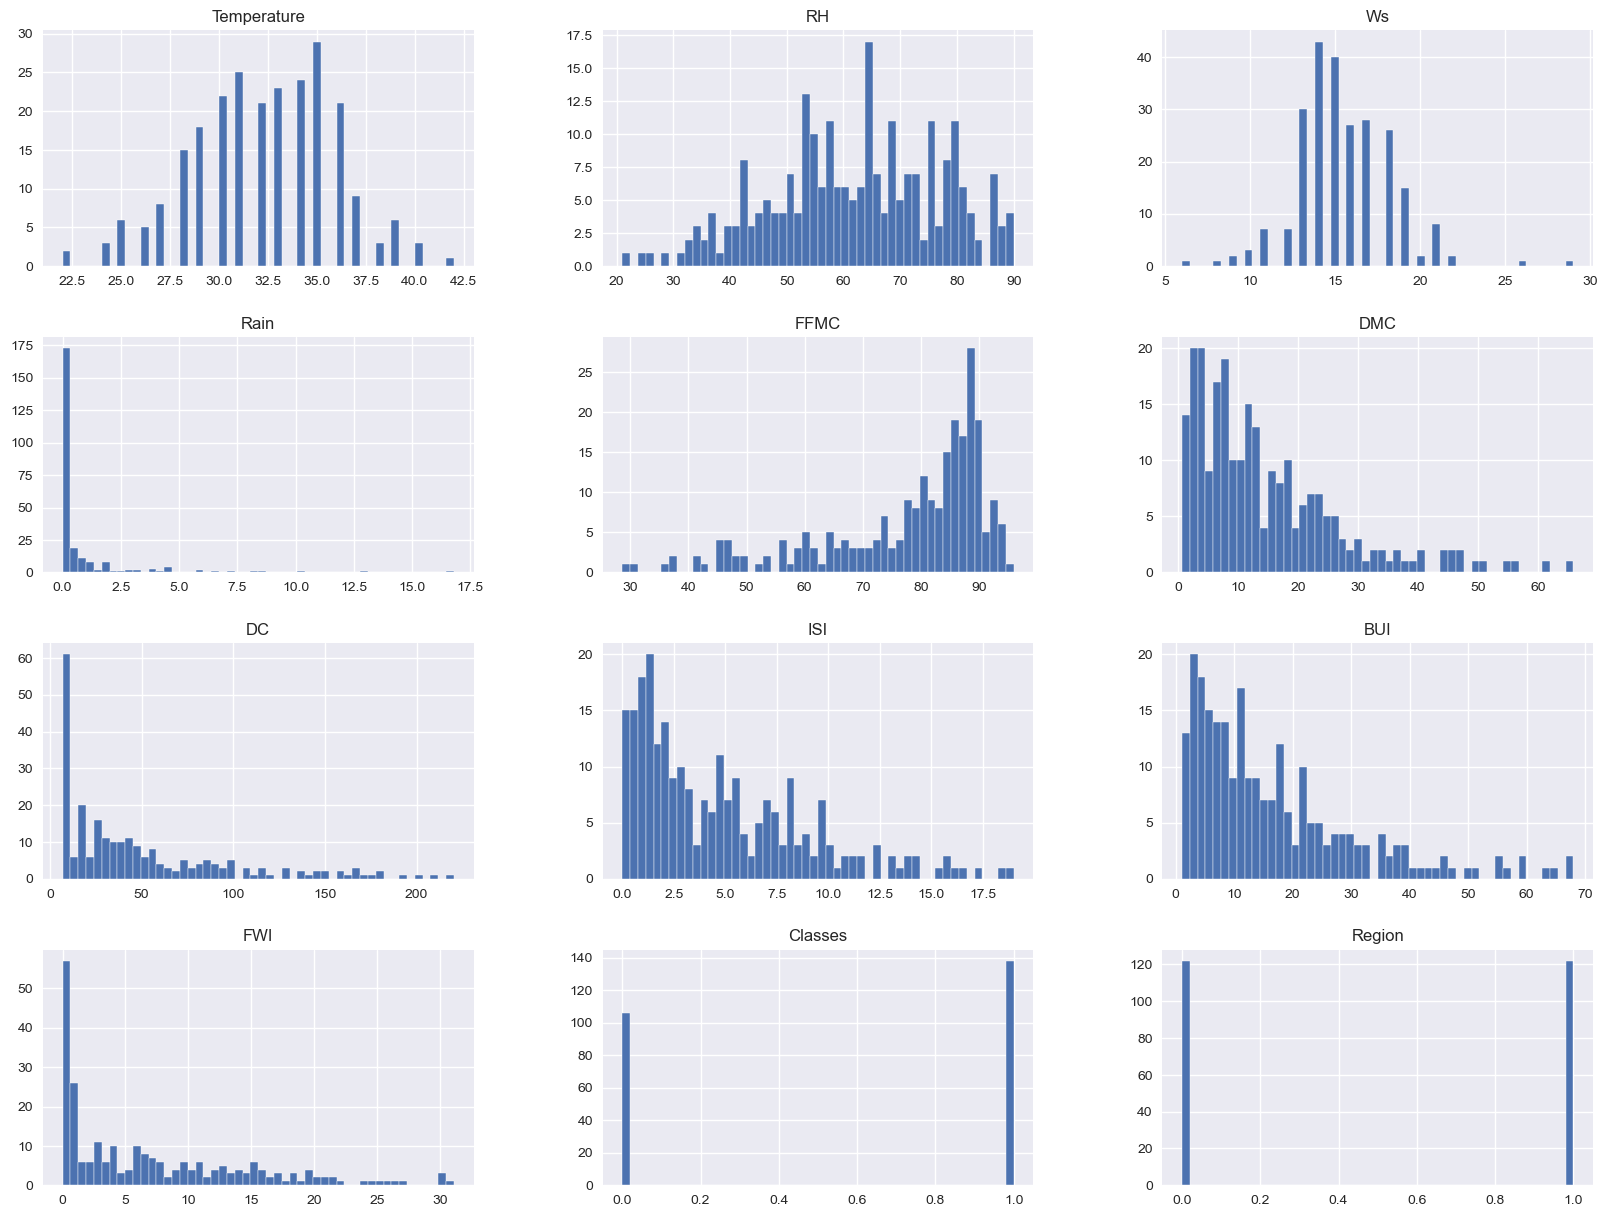

In [555]:
# plot  density plot for all features
 
plt.style.use('seaborn-v0_8')
data.hist(bins = 50 , figsize=(20,15))
plt.show()

In [556]:
 data["Classes"].value_counts(normalize=True)*100

Classes
1    56.557377
0    43.442623
Name: proportion, dtype: float64

In [557]:
percentage = data["Classes"].value_counts(normalize=True)*100

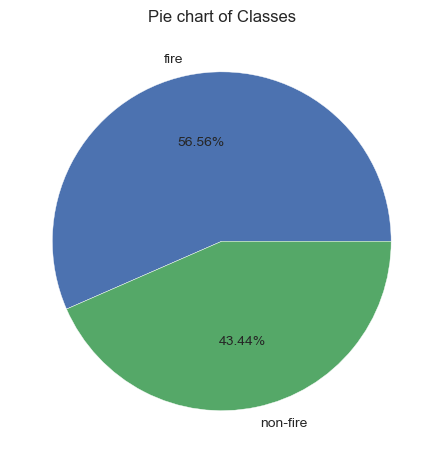

In [558]:
classlabel = ['fire','non-fire']

plt.pie(percentage, labels = classlabel, autopct='%1.2f%%')
plt.title('Pie chart of Classes')
plt.show()

In [559]:
data.corr() 

# if x is positive corresponding to its y it will positive correlation 
# that means if x increases Y also increased

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.654443,-0.278132,-0.326786,0.677491,0.483105,0.374909,0.607551,0.455504,0.564599,0.518119,0.273496
RH,-0.654443,1.000000,0.236084,0.222968,-0.645658,-0.405133,-0.225621,-0.690637,-0.348587,-0.577577,-0.435023,-0.406424
Ws,-0.278132,0.236084,1.000000,0.170169,-0.163255,-0.001246,0.079005,0.015248,0.029756,0.032315,-0.066529,-0.176829
Rain,-0.326786,0.222968,0.170169,1.000000,-0.544045,-0.288548,-0.297975,-0.347105,-0.299171,-0.324369,-0.379449,-0.041080
FFMC,0.677491,-0.645658,-0.163255,-0.544045,1.000000,0.602391,0.506778,0.739730,0.589652,0.690289,0.770114,0.224680
DMC,0.483105,-0.405133,-0.001246,-0.288548,0.602391,1.000000,0.875887,0.674499,0.982073,0.875827,0.584188,0.191094
DC,0.374909,-0.225621,0.079005,-0.297975,0.506778,0.875887,1.000000,0.505032,0.941610,0.739521,0.510315,-0.078572
ISI,0.607551,-0.690637,0.015248,-0.347105,0.739730,0.674499,0.505032,1.000000,0.635891,0.916343,0.735511,0.268421
BUI,0.455504,-0.348587,0.029756,-0.299171,0.589652,0.982073,0.941610,0.635891,1.000000,0.857628,0.583882,0.087370
FWI,0.564599,-0.577577,0.032315,-0.324369,0.690289,0.875827,0.739521,0.916343,0.857628,1.000000,0.718079,0.196696


<Axes: >

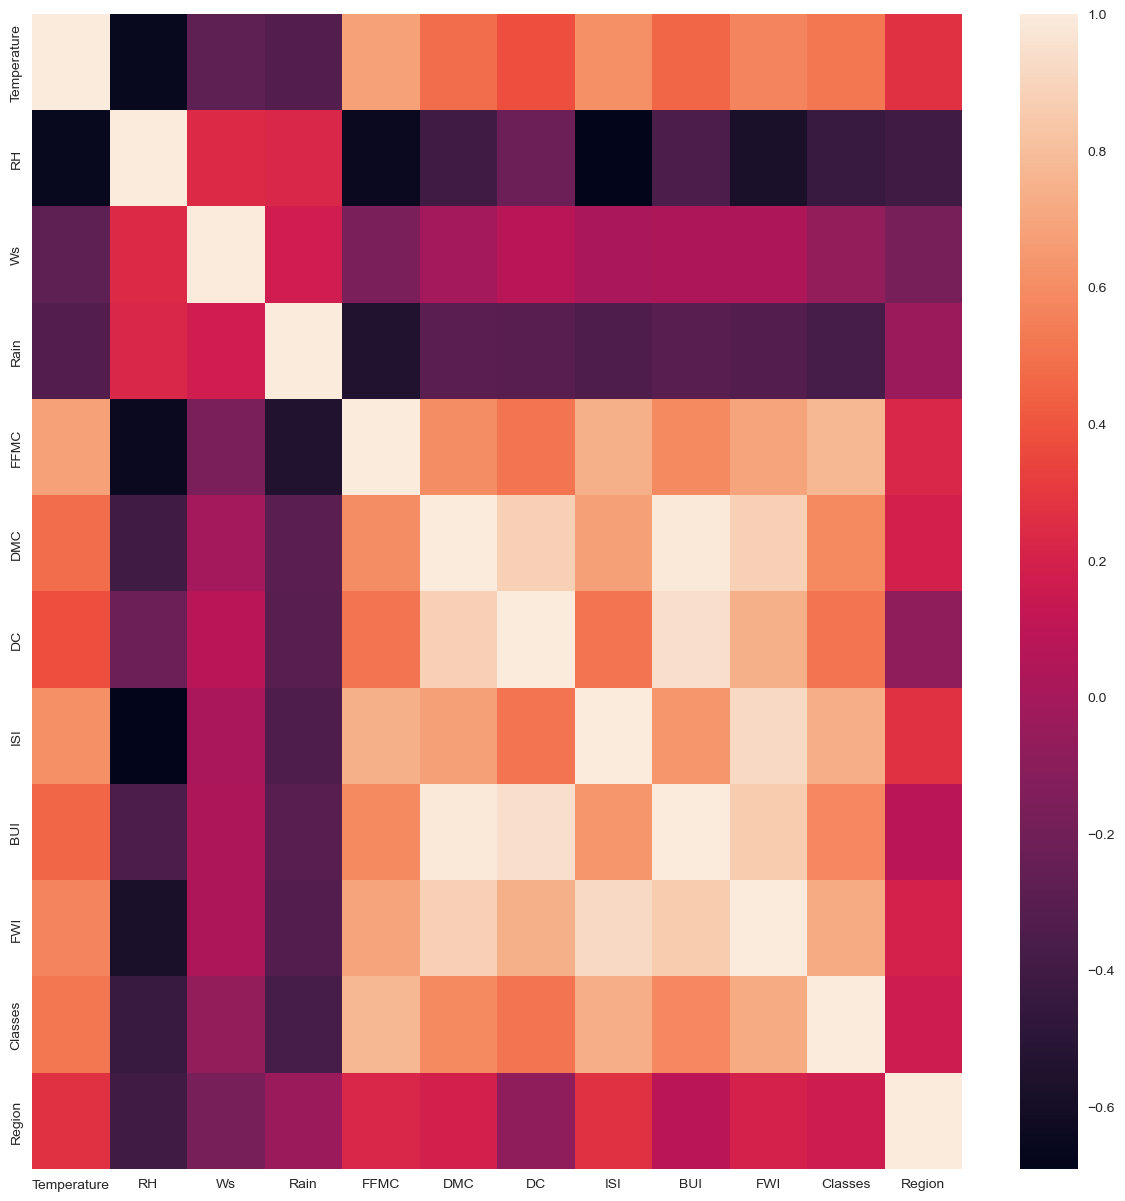

In [560]:
plt.figure(figsize=(15,15))

sns.heatmap(data.corr())


<Axes: ylabel='FWI'>

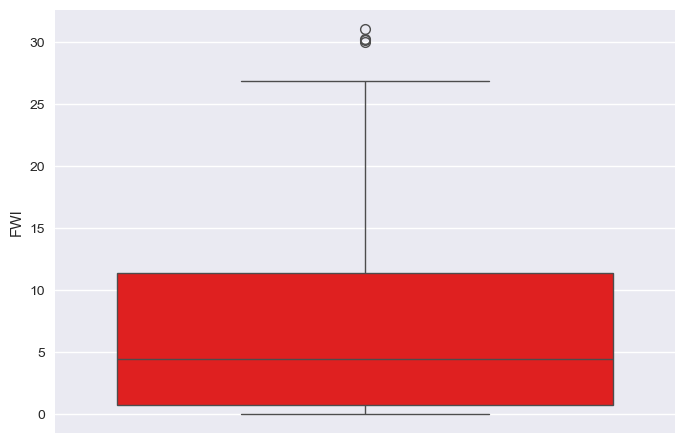

In [561]:
sns.boxplot(data.FWI,color='red') # for FWI our target feature here checking the the outliers

In [562]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [563]:
# Monthly basis fire data analysis
# as there is very high chance to summer season fire

df_temp = dataset.loc[data['Region'] == 1]
df_temp

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
123,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1
124,2,6,2012,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire,1
125,3,6,2012,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire,1
126,4,6,2012,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,not fire,1
127,5,6,2012,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
241,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
242,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
243,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [564]:
dataset['Classes'] = np.where(dataset['Classes'].str.contains('not fire'),'not fire','fire')

Text(0.5, 1.0, 'Fire analysis of Algerion forest')

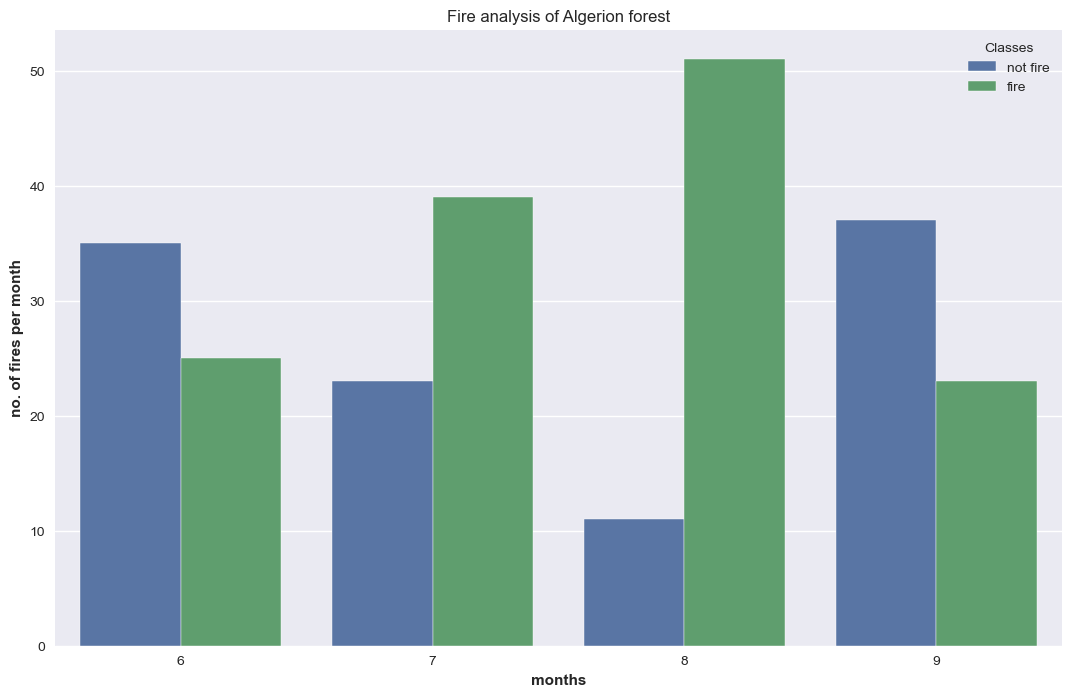

In [569]:
plt.subplots(figsize = (13,8))
sns.set_style('darkgrid')
sns.countplot(x = 'month', hue ='Classes', data = dataset)

plt.xlabel('months',weight = 'bold')
plt.ylabel('no. of fires per month' , weight = 'bold')
plt.title('Fire analysis of Algerion forest')

## Observation

- August = MAx fire
- September = Lowest fire no.